# Task 1: Import Necessary Libraries

In [7]:
# Import jax.numpy and any other libraries we might need
import pandas as pd
import numpy as np
import jax.numpy as jnp
import numpyro
import seaborn as sns
import matplotlib.pyplot as plt

# Import the relevant modules of the lightweight_mmm library
from lightweight_mmm import lightweight_mmm
from lightweight_mmm import optimize_media
from lightweight_mmm import plot
from lightweight_mmm import preprocessing
from lightweight_mmm import utils

ModuleNotFoundError: No module named 'pandas'

# Task 2: Load the Dataset

In [ ]:
# Load and print the dataset
df = pd.read_csv("/usercode/data.csv")

In [ ]:
df.head()

,Date,Sales,adwords_spending,facebookads_spending,awin_spending,tiktok_spending,snapchat_spending
0,2021-01-08,26865.0,3426.0,1861.0,1287.0,1432.0,1532.0
1,2021-01-15,22850.0,2912.0,1919.0,1022.0,1278.0,1682.0
2,2021-01-22,32856.0,5150.0,4161.0,1123.0,1615.0,778.0
3,2021-01-29,35756.0,1416.0,1097.0,1129.0,1284.0,1142.0
4,2021-02-05,29125.0,3093.0,3544.0,817.0,1171.0,1163.0


# Task 3: Explore the Dataset

In [ ]:
# Check for missing values
df.isna().sum()

Date                    0
Sales                   0
adwords_spending        2
facebookads_spending    2
awin_spending           2
tiktok_spending         2
snapchat_spending       2
dtype: int64

In [ ]:
# Print a concise summary of the dataframe
df.describe()

,Sales,adwords_spending,facebookads_spending,awin_spending,tiktok_spending,snapchat_spending
count,156.000000,154.000000,154.000000,154.000000,154.000000,154.000000
mean,35268.814103,3206.240260,2983.389610,1448.909091,1239.162338,1473.337662
std,6350.950726,1217.082255,1078.147608,510.092474,424.362536,484.917569
min,22077.000000,1378.000000,1070.000000,597.000000,451.000000,600.000000
25%,31925.750000,2133.250000,2032.000000,1017.250000,889.750000,1079.250000
50%,34442.000000,3038.500000,3097.500000,1312.500000,1221.000000,1517.000000
75%,37875.500000,4155.500000,3820.500000,1848.000000,1592.500000,1857.750000
max,72194.000000,6024.000000,5691.000000,3207.000000,2753.000000,2574.000000


In [ ]:
# Create a correlation matrix
correlation_matrix = df.corr(numeric_only=True).round(2)
correlation_matrix

,Sales,adwords_spending,facebookads_spending,awin_spending,tiktok_spending,snapchat_spending
Sales,1.00,0.13,0.13,0.35,0.46,0.33
adwords_spending,0.13,1.00,0.10,0.11,0.06,0.00
facebookads_spending,0.13,0.10,1.00,-0.04,0.17,0.10
awin_spending,0.35,0.11,-0.04,1.00,0.16,0.19
tiktok_spending,0.46,0.06,0.17,0.16,1.00,0.10
snapchat_spending,0.33,0.00,0.10,0.19,0.10,1.00


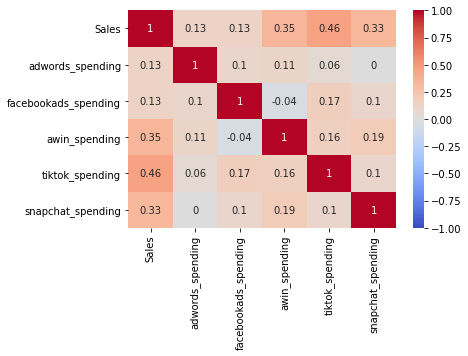

In [ ]:
# Plot a heatmap to visualize the correlation
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm',vmin=-1,vmax=1)
plt.show()

<AxesSubplot: xlabel='Date'>

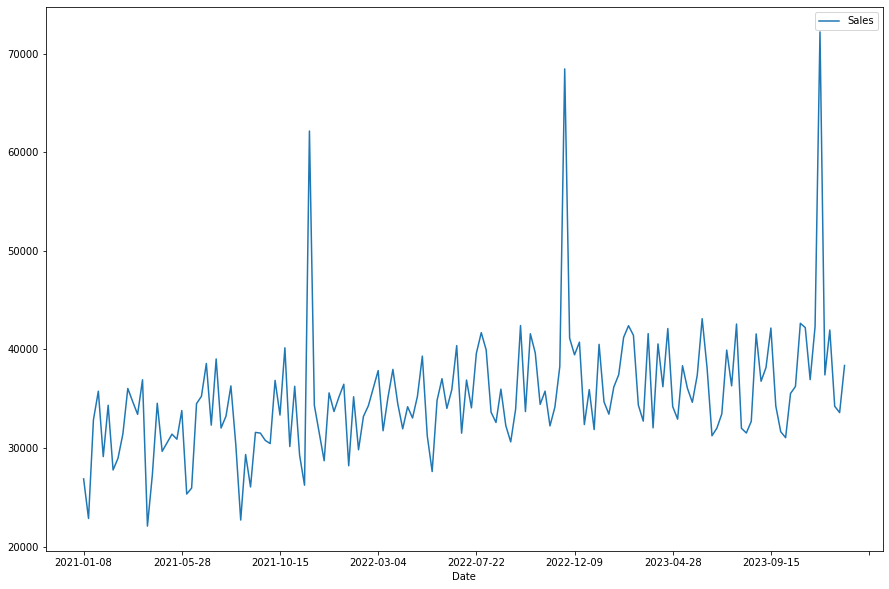

In [ ]:
# Plot the amount of Sales over time
df.plot.line(x="Date",y="Sales",figsize=(15,10))

# Task 4: Preprocess the Data

In [ ]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df["Date"])

In [ ]:
# Create a binary varible to flag Black Fridays (0 or 1)
black_friday_dates = [
    pd.Timestamp('2021-11-26'),
    pd.Timestamp('2022-11-25'),
    pd.Timestamp('2023-11-24')
]

df["black_friday"] = df["Date"].isin(black_friday_dates).astype(int)

In [ ]:
# Fill missing values
df = df.fillna(0)

In [ ]:
n = df.shape[0]
split_point = int(n*0.8)
train = df[:split_point]
test = df[split_point:]

In [ ]:
media = ["adwords_spending", "facebookads_spending", "awin_spending", "tiktok_spending", "snapchat_spending"]
extra_features = ["black_friday"]
target = ["Sales"]
costs = np.ones(5)

media_scaler = preprocessing.CustomScaler(divide_operation=jnp.mean)

extra_feature_scaler = preprocessing.CustomScaler(divide_operation=jnp.mean)

target_scaler = preprocessing.CustomScaler(divide_operation=jnp.mean)

cost_scaler = preprocessing.CustomScaler(divide_operation=jnp.mean)

scaled_costs = cost_scaler.fit_transform(np.array(costs))

scaled_media_train = media_scaler.fit_transform(train[media].to_numpy())

scaled_extra_features_train = extra_feature_scaler.fit_transform(train[extra_features].to_numpy())

scaled_target_train = target_scaler.fit_transform(train[target].to_numpy())

scaled_media_test = media_scaler.transform(test[media].to_numpy())
scaled_extra_features_test = extra_feature_scaler.transform(test[extra_features].to_numpy())

scaled_target_test = target_scaler.transform(test[target].to_numpy())

# Task 5: Train a Marketing Mix Model

In [ ]:
# Call the LightweightMMM object
mmm = lightweight_mmm.LightweightMMM(model_name="carryover")

# Train the model
mmm.fit(media=scaled_media_train,
extra_features=scaled_extra_features_train,
    media_prior=scaled_costs,
    target=scaled_target_train,
    number_warmup=100,
    number_samples=300,
    number_chains=1)

sample: 100%|██████████| 400/400 [00:07<00:00, 56.57it/s, 12 steps of size 8.54e-03. acc. prob=0.15] 


# Task 6: Check for Convergence

In [ ]:
# Print the model summary
mmm.print_summary()


                                 mean       std    median      5.0%     95.0%     n_eff     r_hat
ad_effect_retention_rate[0]      0.63      0.00      0.63      0.63      0.63     12.23      1.10
ad_effect_retention_rate[1]      0.49      0.00      0.49      0.49      0.49      3.39      1.87
ad_effect_retention_rate[2]      0.56      0.00      0.56      0.56      0.56     15.90      1.12
ad_effect_retention_rate[3]      0.53      0.00      0.53      0.53      0.54      4.03      1.55
ad_effect_retention_rate[4]      0.46      0.00      0.46      0.46      0.46      8.58      1.04
     coef_extra_features[0]     -0.00      0.00     -0.00     -0.00      0.00     80.38      1.01
              coef_media[0]      0.13      0.03      0.12      0.12      0.14     10.51      1.12
              coef_media[1]      0.05      0.03      0.04      0.04      0.05     19.23      1.05
              coef_media[2]      0.03      0.03      0.02      0.02      0.03     21.09      1.05
              coef_

In [ ]:
# Call the LightweightMMM object
mmm = lightweight_mmm.LightweightMMM( model_name="hill_adstock")


# Train the model
mmm.fit(media=scaled_media_train,    extra_features=scaled_extra_features_train,
 media_prior=scaled_costs,
 target=scaled_target_train,
 number_warmup=200,
 number_samples=500,
 number_chains=1)

# Print the model summary

mmm.print_summary()

sample: 100%|██████████| 700/700 [00:56<00:00, 12.37it/s, 1023 steps of size 3.25e-03. acc. prob=0.72]



                                         mean       std    median      5.0%     95.0%     n_eff     r_hat
             coef_extra_features[0]     -0.00      0.00     -0.00     -0.00      0.00    442.02      1.00
                      coef_media[0]      0.05      0.05      0.04      0.00      0.11      6.18      1.22
                      coef_media[1]      0.15      0.15      0.09      0.00      0.37     64.94      1.02
                      coef_media[2]      0.13      0.16      0.07      0.00      0.31     27.94      1.16
                      coef_media[3]      0.68      0.38      0.57      0.15      1.30      7.72      1.08
                      coef_media[4]      0.09      0.11      0.05      0.00      0.17     14.40      1.16
                      coef_trend[0]     -0.00      0.00     -0.00     -0.00      0.00    245.04      1.00
                         expo_trend      0.95      0.04      0.95      0.88      1.00      8.46      1.00
             gamma_seasonality[0,0]      0.00

# Task 7: Evaluate the Model

In [ ]:
# Use the model to get predictions for the test set

prediction = mmm.predict(
  media=test[media].to_numpy(),
  extra_features=test[extra_features].to_numpy(),
  target_scaler=target_scaler
)

In [ ]:
# Get the mean value of those predictions for each data point
point_prediction = np.mean(prediction, axis=0)

In [ ]:
# Calculate and print the RMSE
rmse = np.sqrt(
  np.mean(
      (test["Sales"]-point_prediction)**2
      )
  )
print(rmse)

7293.2686


# Task 8: Check for Prediction Quality

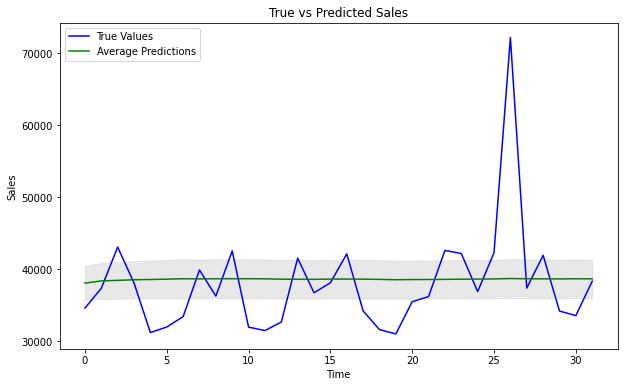

In [ ]:
# Extract the average and range of predictions


# Plotting
# Extract the average and range of predictions
avg_predictions = np.mean(prediction, axis=0)
std_dev_predictions = np.std(prediction, axis=0)
range_predictions = std_dev_predictions*2

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(
  test["Sales"].reset_index(drop=True),
  label="True Values", color='blue')
plt.plot(
  avg_predictions,
  label="Average Predictions",
  color='green')
plt.fill_between(
  range(len(avg_predictions)),
  avg_predictions - range_predictions,
  avg_predictions + range_predictions,
  color='lightgrey', alpha=0.5)

plt.xlabel("Time")
plt.ylabel("Sales")
plt.title("True vs Predicted Sales")
plt.legend()
plt.show()

# Task 9: Check Parameter Estimations

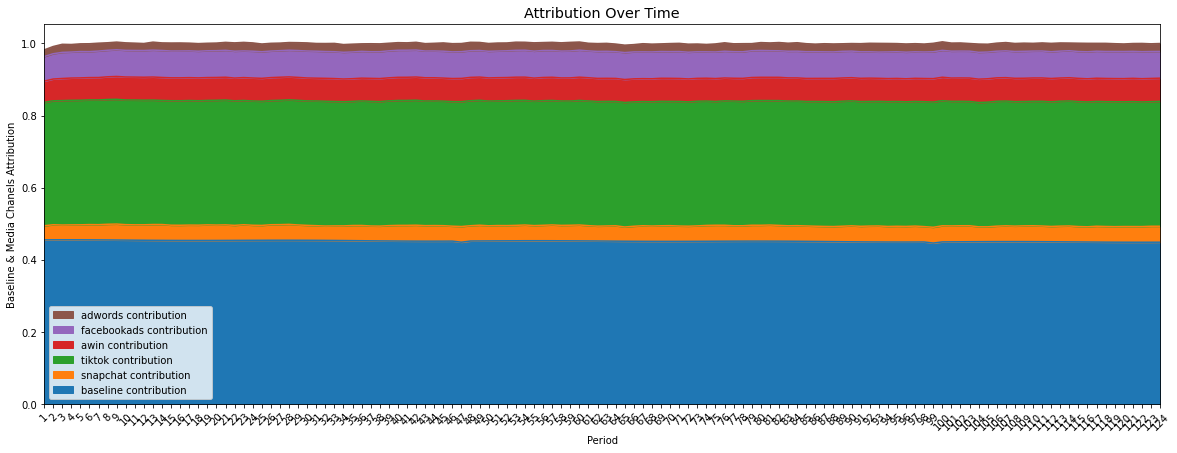

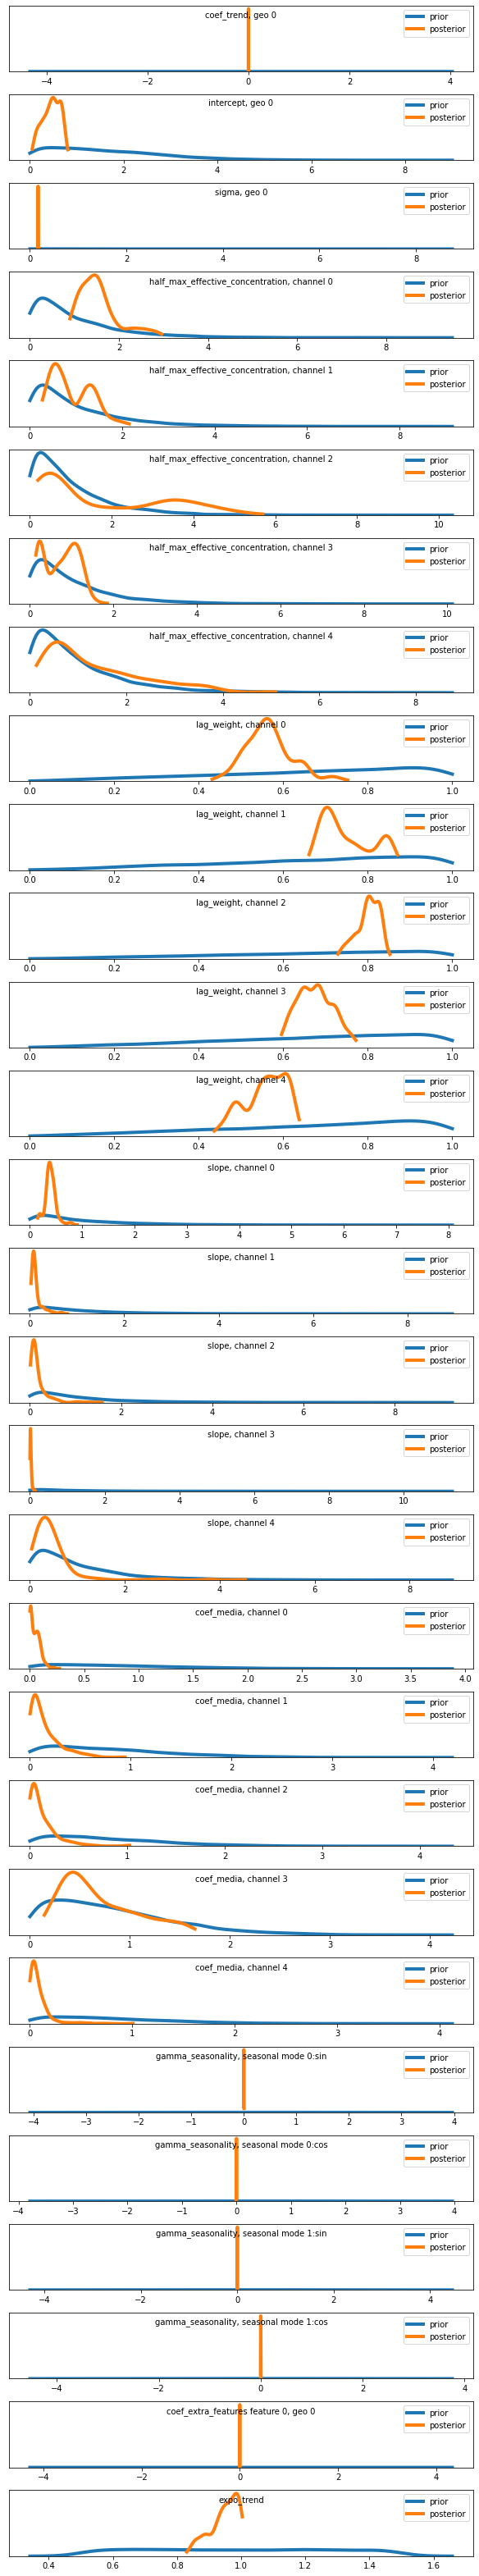

In [ ]:
# Plot media channel priors vs. posteriors

plot.plot_prior_and_posterior(
media_mix_model=mmm)

# Plot the media baseline contributions
plot.plot_media_baseline_contribution_area_plot(
  media_mix_model=mmm,
  channel_names=[name.replace("_spending","") for name in media])



# Task 10: Assess Model Insights

In [ ]:
# Get the estimators for media effect and ROI
media_effect_hat, roi_hat = mmm.get_posterior_metrics(
target_scaler=target_scaler,
cost_scaler=cost_scaler
)

# Calculate and print their mean values
mean_roi = np.mean(roi_hat, axis=0)
mean_media_effect = np.mean(media_effect_hat, axis=0)

print(mean_roi)
print(mean_media_effect)

[  94091.11  317517.56  273727.6  1480620.    183520.53]
[0.02194549 0.07405856 0.0638421  0.34532592 0.04280467]


# Task 11: Optimize Media Spending

In [ ]:
# Define a time frame
time_frame = len(test.Date)

# Define a budget
avg_budget = train[media].mean().sum()
budget = avg_budget * time_frame

# Run media optimization
solution = optimize_media.find_optimal_budgets(
    n_time_periods=time_frame,
    media_mix_model=mmm,
    budget=budget,
    extra_features=scaled_extra_features_test,
    prices=costs,
    media_scaler=media_scaler,
    target_scaler=target_scaler,
    bounds_upper_pct=10
    )

print(solution)

Optimization terminated successfully    (Exit mode 0)
            Current function value: -1105290.2698217542
            Iterations: 42
            Function evaluations: 462
            Gradient evaluations: 42
( message: Optimization terminated successfully
 success: True
  status: 0
     fun: -1105290.2698217542
       x: [ 8.100e+04  7.555e+04  3.793e+04  5.744e+04  7.261e+04]
     nit: 42
     jac: [-6.455e-02 -4.310e-02 -7.506e-02 -7.506e-02 -7.506e-02]
    nfev: 462
    njev: 42, Array(-1103381.55588765, dtype=float64), Array([101249.29228623,  94431.47956916,  45268.64597258,  37776.25901528,
        45796.9038019 ], dtype=float64))


# Task 12: Persist the Model

In [ ]:
# Save the model
utils.save_model(mmm, file_path='/usercode/model')

# Load the model and print its summary
mmm = utils.load_model('/usercode/model')

# Use the model to make predictions on the test set
prediction = mmm.predict(
media=test[media].to_numpy(),
extra_features=test[extra_features].to_numpy(),
target_scaler=target_scaler)

avg_prediction = np.mean(prediction, axis=0)
print(avg_prediction)

[38098.707 38407.46  38482.438 38566.734 38605.184 38652.55  38709.59
 38684.914 38710.984 38710.15  38714.38  38693.445 38651.887 38637.254
 38627.957 38666.473 38664.797 38652.69  38621.188 38573.637 38596.625
 38604.13  38623.14  38650.09  38662.95  38679.883 38739.504 38704.453
 38696.55  38684.13  38706.746 38692.504]


In [ ]:
print(avg_prediction)

[38098.707 38407.46  38482.438 38566.734 38605.184 38652.55  38709.59
 38684.914 38710.984 38710.15  38714.38  38693.445 38651.887 38637.254
 38627.957 38666.473 38664.797 38652.69  38621.188 38573.637 38596.625
 38604.13  38623.14  38650.09  38662.95  38679.883 38739.504 38704.453
 38696.55  38684.13  38706.746 38692.504]
